In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
smcart = pd.read_csv("smartcart_customers.csv")

In [3]:
smcart.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Data Preprocessing

## 1. Handling Missing values

In [4]:
smcart["Income"] = smcart["Income"].fillna(smcart["Income"].median())

In [5]:
smcart.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## 2. Feature Engineering

In [6]:
#  Age
smcart["Age"] = 2026 - smcart["Year_Birth"]

# Tenuer Days

smcart["Dt_Customer"] = pd.to_datetime(smcart["Dt_Customer"], dayfirst = True)

ref_date = smcart["Dt_Customer"].max()
smcart["Tenuer_Days"] = (ref_date - smcart["Dt_Customer"]).dt.days

In [7]:
smcart.head()
smcart.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Tenuer_Days'],
      dtype='str')

In [8]:
# Spending

smcart["Total_Spending"] = (smcart["MntWines"] + smcart["MntFruits"] + smcart["MntMeatProducts"] 
                            + smcart["MntFishProducts"] + smcart["MntSweetProducts"] + smcart["MntGoldProds"])

#  Total Children
smcart["Total_Children"] = smcart["Kidhome"] + smcart["Teenhome"]

In [9]:
#  Education
smcart["Education"].value_counts()
smcart["Education"] = smcart["Education"].replace({
    "Basic" : "Undergraduate",
    "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Postgraduate",
    "PhD" : "Postgraduate"
})
# Undergraduate, Graduate, Postgraduate
smcart["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [10]:
# Maretial Status

smcart["Marital_Status"].value_counts()

smcart["Living_with"] = smcart["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone",
    "Divorced" : "Alone",
    "Widow" : "Alone",
    "Absurd" : "Alone",
    "YOLO" : "Alone"
})
smcart["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

## 3. Drop Columns

In [11]:
smcart.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenuer_Days,Total_Spending,Total_Children,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [12]:
cols = ["ID", "Marital_Status", "Year_Birth", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop = cols + spending_cols

smcart_clean = smcart.drop(columns = cols_to_drop)

In [13]:
smcart_clean.shape
smcart_clean.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenuer_Days,Total_Spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# OUTLIERS 

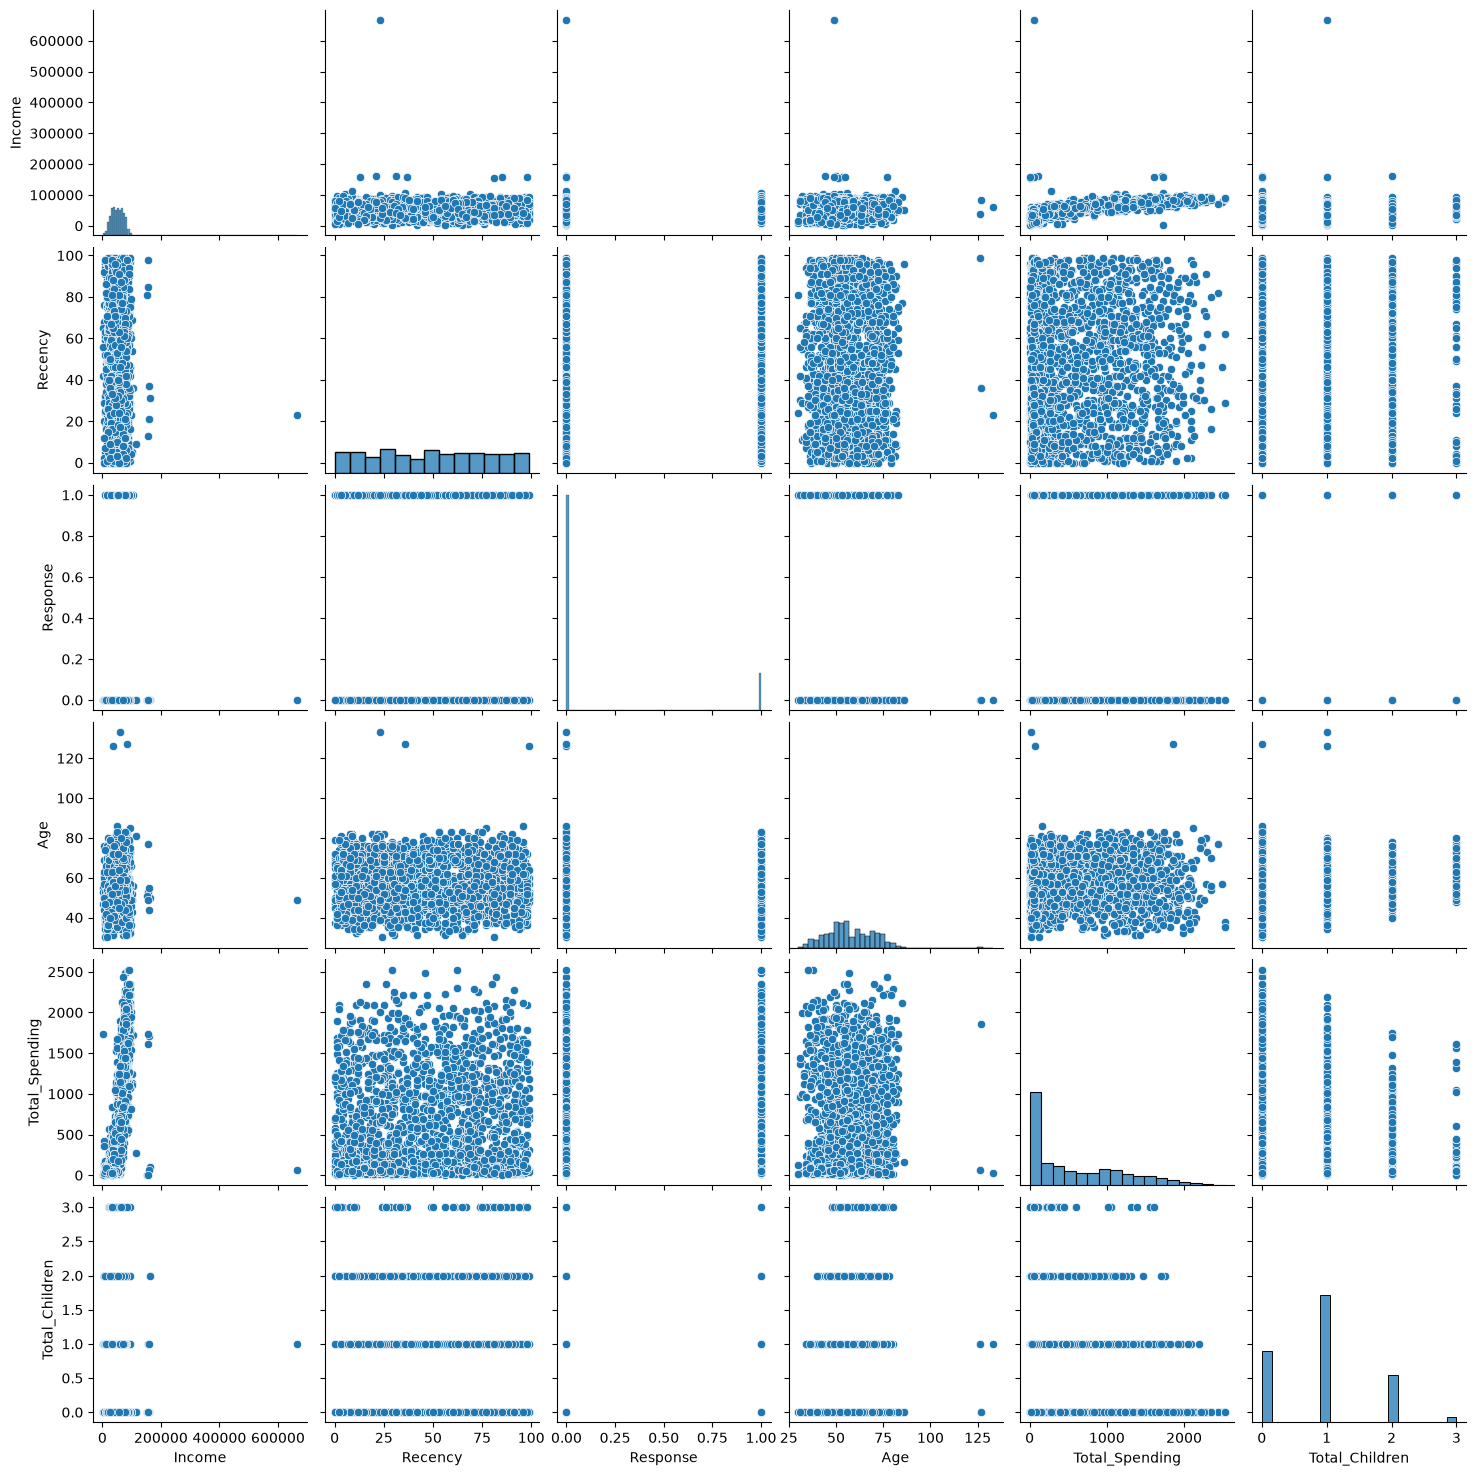

In [14]:
# Looking at outliers

cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features - pair plots
sns.pairplot(smcart_clean[cols])

In [15]:
#  Remove outlier

print(f"1. Data Size with outilers : {len(smcart_clean)}")

smcart_clean = smcart_clean[(smcart_clean["Age"] < 90)]
smcart_clean = smcart_clean[(smcart_clean["Income"] < 600000)]

print(f"\n2. Data Size without outilers : {len(smcart_clean)}")

1. Data Size with outilers : 2240

2. Data Size without outilers : 2236


## HeatMap

In [16]:
corr = smcart_clean.corr(numeric_only = True)

In [17]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenuer_Days,Total_Spending,Total_Children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

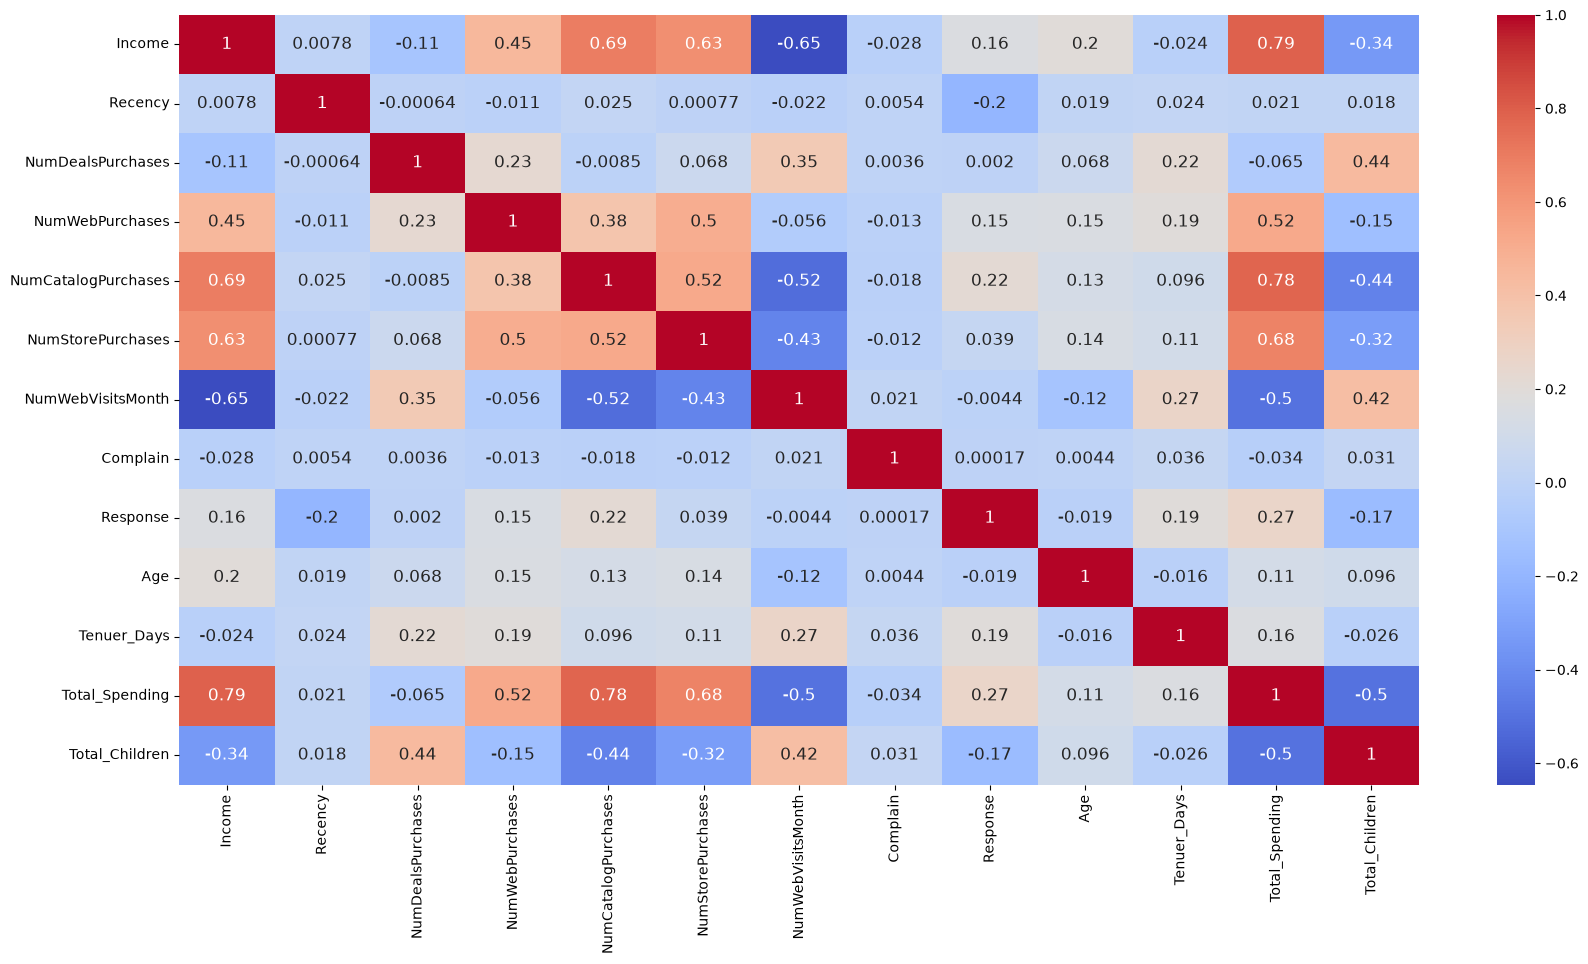

In [18]:
plt.figure(figsize = (20, 10))
sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size" : 12},
    cmap = "coolwarm"
)

# ENCODING

In [19]:
from sklearn.preprocessing import OneHotEncoder

In [20]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_with"]
enc_cols = ohe.fit_transform(smcart_clean[cat_cols])

In [23]:
enc_sm = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = smcart_clean.index)

In [24]:
enc_sms = pd.concat([smcart_clean.drop(columns = cat_cols), enc_sm], axis = 1)

In [25]:
enc_sms.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenuer_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# SCALING DATA

In [26]:
from sklearn.preprocessing import StandardScaler

X = enc_sms
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
X_scaled.shape

(2236, 18)

# Visualization

In [28]:
# 2D Convet
from sklearn.decomposition import PCA

pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

In [29]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D-PLOT')

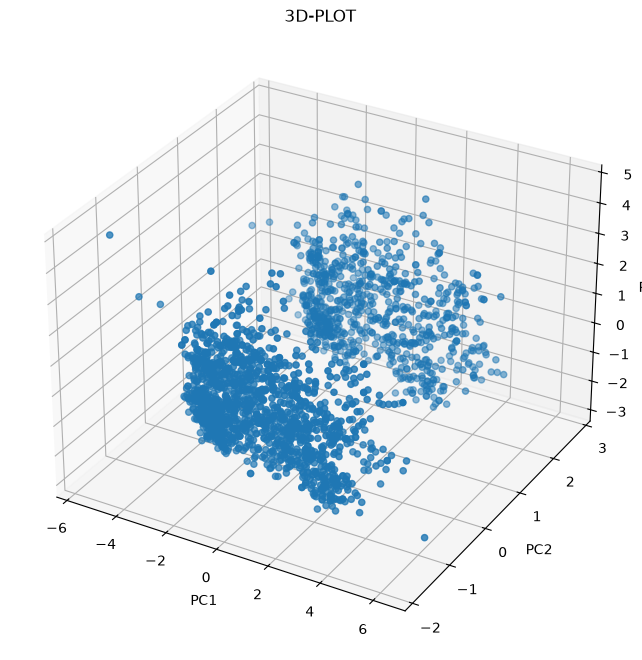

In [30]:
fig = plt.figure(figsize = (8,15))

ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:, 2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D-PLOT")

# Aanalize K - Value

## 1. ELBOW - METHOD

In [33]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [34]:
knee = KneeLocator(range(1, 11), wcss, curve = "convex", direction = "decreasing")
optimal_k = knee.elbow

In [35]:
print(f"Best K : {optimal_k}")

Best K : 4


Text(0, 0.5, 'WCSS')

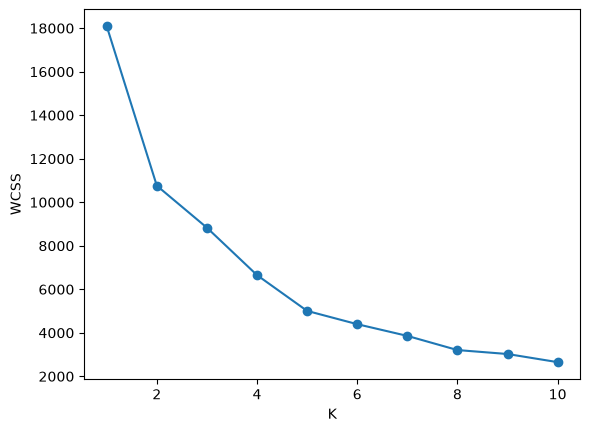

In [36]:
# Plot K
plt.plot(range(1,11), wcss, marker = "o")
plt.xlabel("K")
plt.ylabel("WCSS")

## 2. Sillhouette Score

In [37]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmean = KMeans(n_clusters = k, random_state =42)
    labels = kmean.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

Text(0.5, 1.0, 'Silhouette Value')

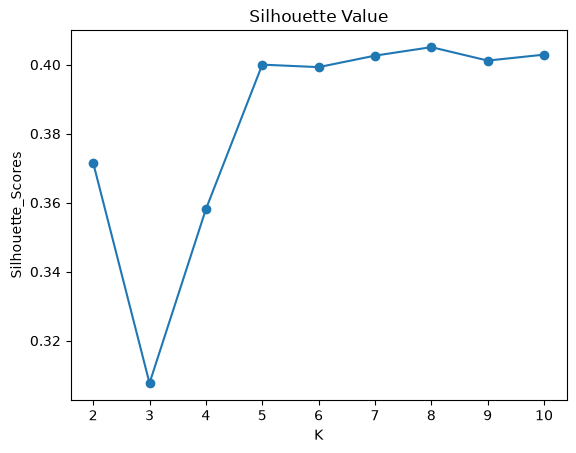

In [38]:
plt.plot(range(2,11), scores, marker = "o")
plt.xlabel("K")
plt.ylabel("Silhouette_Scores")
plt.title("Silhouette Value")

Text(0, 0.5, 'Silhouette_Score')

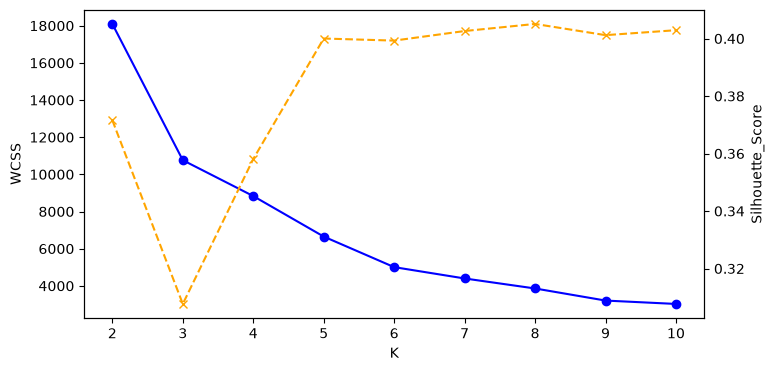

In [39]:
# Combine Plot

k_range = range(2,11)

fig, ax = plt.subplots(figsize =(8, 4))

ax.plot(k_range, wcss[:len(k_range)], marker = "o", color = "blue")
ax.set_xlabel("K")
ax.set_ylabel("WCSS")
ax1 = ax.twinx()
ax1.plot(k_range, scores[:len(k_range)], marker = "x", linestyle = "--", color = "orange")
ax1.set_ylabel("Silhouette_Score")

# CLUSTERING

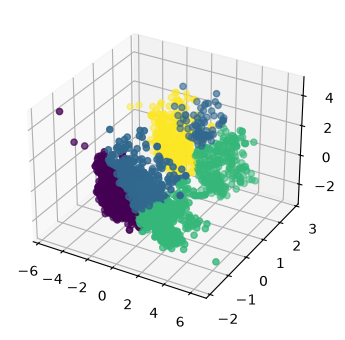

In [40]:
# K-Mena

kmeans = KMeans(n_clusters = 4, random_state = 42)
k_labels = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize = (4, 4))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = k_labels)

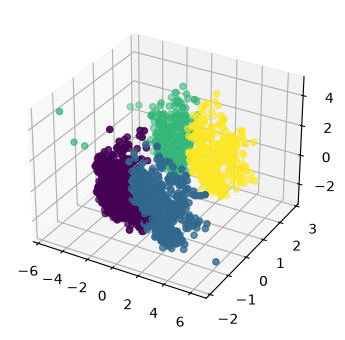

In [41]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
ag_labels = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize =(4,4))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = ag_labels)

# CHARACTERIZATION OF CLUSTERS

In [42]:
X["clusters"] = ag_labels

In [43]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenuer_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

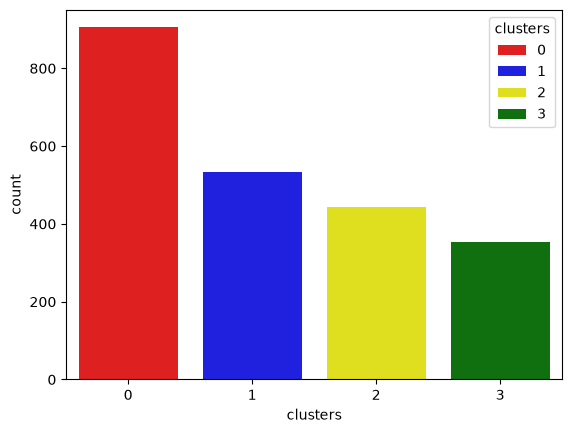

In [44]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x = X["clusters"], palette = pal, hue = X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

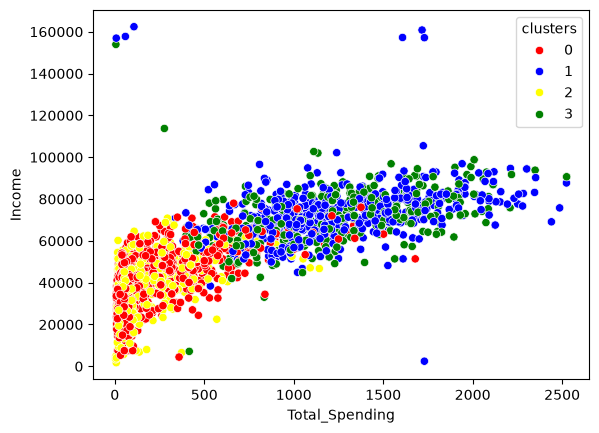

In [45]:
# Check Income and Spending Patterns
sns.scatterplot(x = X["Total_Spending"], y = X["Income"], hue = X["clusters"], palette = pal)

In [46]:
# Cluster Summary

cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Tenuer_Days  Total_Spending  Total_Children